# GAT on hard-negative-aware data

2-layer multi-head GAT encoder + MLP decoder + BPR loss.

1. **Data dir**: `data/processed_v2/`. Prep saves `negatives_random` + `negatives_hard` (training) and `negative_locals_mixed` (eval).
2. **`NEG_STRATEGY` flag** — `'random' | 'hard' | 'mixed'`. Default `'mixed'`.
3. **Eval reads `negative_locals_mixed`** — 50/50 hard/random regime.
4. **Full-pool test eval (T1)** — `evaluate_full_pool()` ranks against ~546K papers using `known_locals` to mask.

Author representation: mean-pool of paper embeddings over the author's pre-year history. **No learned author embedding table** anywhere in this notebook — model stays fully inductive (any new user with a list of read papers can be embedded immediately, addressing the cold-start scenario).


## Imports

PyTorch + PyG. We import `GATConv` for the encoder.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path

from torch_geometric.nn import GATConv

## Reproducibility and device

Pin random seeds (Python, NumPy, PyTorch, CUDA) so a re-run produces the exact training trajectory. Auto-pick GPU when available.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

All knobs in one place.

Key knobs:
- **`NEG_STRATEGY`** — picks training negatives from the pre-computed `negatives_random` / `negatives_hard` lists. Default `'mixed'` aligns with the eval pool composition.
- **`GAT_HEADS_LAYER1=4`** — 4 parallel attention heads in the first layer, concatenated -> `HIDDEN_DIM=256` total. Each head learns a different attention pattern over neighbors.
- **`GAT_HEADS_LAYER2=1`** — single head in the output layer (standard practice; multi-head averaging is unnecessary at the final layer).
- **`NUM_EPOCHS=60`**.
- **`GRAD_CLIP_NORM=0.0`** — disabled by default. If GAT shows unstable training (NaN losses), set to `1.0`.


In [3]:
# --- Paths ---
PROCESSED_DIR = Path("./data/processed_v2")    # v2 prep output
MODEL_OUT_DIR = Path("./models")
PLOTS_OUT_DIR = Path("./data")

# --- Negative strategy (NEW in v2) ---
NEG_STRATEGY = 'mixed'   # 'random' | 'hard' | 'mixed'

# --- Encoder (GAT) ---
INPUT_DIM = 768
HIDDEN_DIM = 256
OUTPUT_DIM = 256
GAT_HEADS_LAYER1 = 4
GAT_HEADS_LAYER2 = 1
GAT_NEGATIVE_SLOPE = 0.2
DROPOUT = 0.2
ATTN_DROPOUT = 0.0

# --- Decoder (MLP) ---
DECODER_HIDDEN_DIM = 256
DECODER_DROPOUT = 0.0

# --- Optimization ---
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 0.0

# --- Training ---
NUM_EPOCHS = 60
BATCH_SIZE = 512
EVAL_EVERY = 5
GNN_GRAD_SAMPLE_SIZE = 32

# --- Eval ---
EVAL_BATCH_SIZE = 64

print(f"Data dir:      {PROCESSED_DIR}")
print(f"NEG_STRATEGY:  {NEG_STRATEGY}")
print(f"GAT:           layers=2, heads_l1={GAT_HEADS_LAYER1}, heads_l2={GAT_HEADS_LAYER2}")
print(f"Dims:          {INPUT_DIM} -> {HIDDEN_DIM} -> {OUTPUT_DIM}, dropout={DROPOUT}, attn_dropout={ATTN_DROPOUT}")
print(f"Optim:         Adam(lr={LR}, wd={WEIGHT_DECAY}), grad_clip={GRAD_CLIP_NORM}")
print(f"Schedule:      {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}")

Data dir:      data/processed_v2
NEG_STRATEGY:  mixed
GAT:           layers=2, heads_l1=4, heads_l2=1
Dims:          768 -> 256 -> 256, dropout=0.2, attn_dropout=0.0
Optim:         Adam(lr=0.001, wd=1e-05), grad_clip=0.0
Schedule:      60 epochs, batch 512, eval every 5


## Step 1 — Load data

Load `train_years.pt`, `metadata.pt`, `val.pt`. Per-year training files are loaded lazily inside the loop so peak memory is bounded by one year's graph + supervision.


In [4]:
train_years = torch.load(PROCESSED_DIR / "train_years.pt", weights_only=False)
metadata = torch.load(PROCESSED_DIR / "metadata.pt", weights_only=False)
val_data = torch.load(PROCESSED_DIR / "val.pt", weights_only=False)

print(f"Training years ({len(train_years)}): {train_years}")
print(f"Embed dim:   {metadata['embed_dim']}")
print(f"FoS level:   {metadata['fos_level']}")
print(f"Eval pool:   {metadata['eval_total_candidates']} candidates, hard frac {metadata['eval_hard_frac']}")
print(f"Val graph:   {val_data['homo_graph'].num_nodes:,} papers, {val_data['homo_graph'].edge_index.shape[1]:,} edges")
print(f"Val examples: {len(val_data['supervision']):,}")

assert metadata['embed_dim'] == INPUT_DIM, f"INPUT_DIM mismatch ({INPUT_DIM} vs {metadata['embed_dim']})"

Training years (12): [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Embed dim:   768
FoS level:   2
Eval pool:   1000 candidates, hard frac 0.5
Val graph:   456,776 papers, 8,993,796 edges
Val examples: 43,562


## Sanity peek at one training year

Confirms the schema. Each training example must have `negatives_random` and `negatives_hard`.


In [5]:
sample_data = torch.load(PROCESSED_DIR / f"train_year_{train_years[0]}.pt", weights_only=False)
print(f"Sample year {train_years[0]}: {sample_data['homo_graph'].num_nodes:,} papers, "
      f"{len(sample_data['supervision']):,} examples")
if sample_data['supervision']:
    ex = sample_data['supervision'][0]
    print(f"  Example keys: {list(ex.keys())}")
    print(f"  Sizes: {len(ex['positive_locals'])} pos, "
          f"{len(ex['negatives_random'])} rand-neg, "
          f"{len(ex['negatives_hard'])} hard-neg, "
          f"{len(ex['history_locals'])} history")
    assert 'negatives_random' in ex and 'negatives_hard' in ex, \
        "Expected v2 schema. PROCESSED_DIR may be pointing at v1."

Sample year 2005: 107,163 papers, 14,780 examples
  Example keys: ['author_id', 'positive_locals', 'negatives_random', 'negatives_hard', 'history_locals']
  Sizes: 3 pos, 15 rand-neg, 15 hard-neg, 13 history


## Step 2 — GAT encoder

Two GAT layers with multi-head attention. Per-layer behavior:
1. Compute attention scores `e(i, j)` for each edge (i, j) using a tiny MLP over `[h_i, h_j]`.
2. Softmax over `i`'s neighbors → attention weights `α(i, j)`.
3. Update `h_i = sum_j α(i, j) * W h_j`.
4. Multiple heads run in parallel and concatenate (layer 1) or use a single head (layer 2).

`heads_l1=4` with `concat=True` requires `HIDDEN_DIM` divisible by `heads_l1` (each head produces `HIDDEN_DIM/heads_l1` dims, concatenated back to `HIDDEN_DIM`). `heads_l2=1` with `concat=False` produces `OUTPUT_DIM` directly.

ELU activation between layers (smoother gradients than ReLU; standard for GAT).

In [7]:
class GATEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,
                 heads_l1=4, heads_l2=1,
                 dropout=0.2, attn_dropout=0.0,
                 negative_slope=0.2):
        super().__init__()
        assert hidden_dim % heads_l1 == 0, \
            f"HIDDEN_DIM ({hidden_dim}) must be divisible by heads_l1 ({heads_l1})"
        per_head_dim = hidden_dim // heads_l1

        self.conv1 = GATConv(
            in_channels=input_dim,
            out_channels=per_head_dim,
            heads=heads_l1,
            concat=True,
            negative_slope=negative_slope,
            dropout=attn_dropout,
        )
        self.conv2 = GATConv(
            in_channels=hidden_dim,
            out_channels=output_dim,
            heads=heads_l2,
            concat=(heads_l2 > 1),
            negative_slope=negative_slope,
            dropout=attn_dropout,
        )
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index)
        return h

### Sanity test — encoder shape and validity

Encode the small sample-year graph, confirm shape `(N, OUTPUT_DIM)`, no NaN/Inf, non-degenerate output.

In [8]:
test_encoder = GATEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE,
)
test_graph = sample_data['homo_graph']
test_encoder.eval()
with torch.no_grad():
    test_out = test_encoder(test_graph.x, test_graph.edge_index)
print(f"In: {test_graph.x.shape}  Out: {test_out.shape}")
assert test_out.shape == (test_graph.num_nodes, OUTPUT_DIM)
assert not torch.isnan(test_out).any() and not torch.isinf(test_out).any()
if test_graph.num_nodes >= 2:
    assert not torch.allclose(test_out[0], test_out[1])
print(f"GAT encoder params: {sum(p.numel() for p in test_encoder.parameters()):,}")
print("[PASS] encoder")
del test_encoder, test_out

In: torch.Size([107163, 768])  Out: torch.Size([107163, 256])
GAT encoder params: 263,680
[PASS] encoder


## Step 3 — MLP decoder

Concatenates author + paper embedding (256-dim total), passes through `Linear(256 -> DECODER_HIDDEN_DIM) -> ReLU -> (optional Dropout) -> Linear(-> 1)` to produce a scalar score.


In [9]:
class MLPDecoder(nn.Module):
    def __init__(self, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(2 * emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, author_emb, paper_emb):
        combined = torch.cat([author_emb, paper_emb], dim=-1)
        h = F.relu(self.fc1(combined))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)

### Sanity test — decoder

Random inputs, confirm scalar-per-pair output, no NaN, non-zero variance.

In [10]:
td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT)
fa, fp = torch.randn(16, OUTPUT_DIM), torch.randn(16, OUTPUT_DIM)
with torch.no_grad():
    s = td(fa, fp)
assert s.shape == (16,) and not torch.isnan(s).any() and s.std() > 0
print(f"Decoder params: {sum(p.numel() for p in td.parameters()):,}")
print("[PASS] decoder")
del td, fa, fp, s

Decoder params: 131,585
[PASS] decoder


## Step 4 — Author representation (mean-pool)

Mean of the author's pre-year paper embeddings. Fully inductive — works for any new author at recommendation time. The history-ID tensor is created on the same device as the paper embeddings to avoid CPU↔GPU shuffles.

In [11]:
def compute_author_embeddings(paper_embeddings, supervision_examples):
    embs = []
    for ex in supervision_examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=paper_embeddings.device)
        embs.append(paper_embeddings[hids].mean(dim=0))
    return torch.stack(embs)

### Sanity test — mean-pool

Hand-compute the expected mean for one author, confirm exact match.

In [12]:
fpe = torch.randn(50, OUTPUT_DIM)
fex = [
    {'history_locals': [0, 1, 2]},
    {'history_locals': [10]},
    {'history_locals': [3, 7]},
]
ae = compute_author_embeddings(fpe, fex)
assert ae.shape == (3, OUTPUT_DIM)
assert torch.allclose(ae[0], fpe[[0, 1, 2]].mean(dim=0))
assert torch.allclose(ae[1], fpe[10])
print("[PASS] mean-pool")
del fpe, fex, ae

[PASS] mean-pool


## Step 5 — BPR loss

Pair every positive with every negative in the example, push positive's score above negative's via `-log sigmoid(pos - neg)`. Average over all pairs.


In [13]:
def bpr_loss(pos_scores, neg_scores):
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

### Sanity test — BPR loss ordering

`pos >> neg` near 0; `pos << neg` large; equal `log(2) ≈ 0.693`.

In [14]:
lg = bpr_loss(torch.tensor([5., 6.]), torch.tensor([-5., -6.])).item()
lb = bpr_loss(torch.tensor([-5., -6.]), torch.tensor([5., 6.])).item()
le = bpr_loss(torch.tensor([0., 0.]), torch.tensor([0., 0.])).item()
print(f"good={lg:.4f}  bad={lb:.4f}  equal={le:.4f}")
assert lg < le < lb and abs(le - 0.6931) < 0.01
print("[PASS] BPR")

good=0.0000  bad=11.0000  equal=0.6931
[PASS] BPR


## Step 6 — Negative-sampling helper

At training time we pick from the pre-computed lists according to `NEG_STRATEGY`:
- `random` -> first N from `negatives_random`.
- `hard` -> first N from `negatives_hard`.
- `mixed` -> half from each.


In [15]:
def get_train_negatives(ex, strategy):
    if strategy == 'random':
        return list(ex['negatives_random'])
    if strategy == 'hard':
        return list(ex['negatives_hard'])
    n = len(ex['negatives_random'])
    half = n // 2
    return list(ex['negatives_random'][:half]) + list(ex['negatives_hard'][:n - half])

## Step 7 — Train one year (GPU-efficient)

Memory strategy:
1. Encode all papers once with `.detach()` — keeps the GNN computation graph out of the per-batch backward passes.
2. Vectorize per-batch scoring — collect all (author, pos+neg paper) pairs into flat tensors, one decoder forward.
3. After all batches, do **one** GNN gradient pass on a small sample so the encoder learns too.

Optional `grad_clip` (default off) — turn on by setting `GRAD_CLIP_NORM=1.0` if GAT training shows NaN losses (multi-head attention can occasionally produce sharper gradients than SAGE).

Negatives are pulled per-example via `get_train_negatives(ex, NEG_STRATEGY)`.


In [16]:
def train_one_year(encoder, decoder, optimizer, year_data, device,
                   batch_size=512, gnn_sample_size=32, grad_clip=0.0,
                   neg_strategy='mixed'):
    encoder.train(); decoder.train()
    graph = year_data['homo_graph'].to(device)
    examples = year_data['supervision']
    if not examples:
        return 0.0

    paper_embs = encoder(graph.x, graph.edge_index).detach()

    indices = list(range(len(examples)))
    random.shuffle(indices)
    total_loss, num_batches = 0.0, 0

    for batch_start in range(0, len(indices), batch_size):
        bidx = indices[batch_start:batch_start + batch_size]
        bex = [examples[i] for i in bidx]
        author_embs = compute_author_embeddings(paper_embs, bex)

        all_a, all_p, bounds = [], [], []
        offset = 0
        for i, ex in enumerate(bex):
            negs = get_train_negatives(ex, neg_strategy)
            if not negs:
                continue
            n_pos, n_neg = len(ex['positive_locals']), len(negs)
            pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
            neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
            all_a.append(author_embs[i].unsqueeze(0).expand(n_pos + n_neg, -1))
            all_p.append(torch.cat([paper_embs[pos_ids], paper_embs[neg_ids]], dim=0))
            bounds.append((offset, n_pos, n_neg))
            offset += n_pos + n_neg
        if not all_a:
            continue

        flat_a = torch.cat(all_a, dim=0)
        flat_p = torch.cat(all_p, dim=0)
        scores = decoder(flat_a, flat_p)

        batch_loss = torch.tensor(0.0, device=device)
        for start, n_pos, n_neg in bounds:
            ps = scores[start:start + n_pos]
            ns = scores[start + n_pos:start + n_pos + n_neg]
            batch_loss = batch_loss + bpr_loss(ps, ns)
        batch_loss = batch_loss / len(bounds)

        optimizer.zero_grad()
        batch_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()),
                max_norm=grad_clip,
            )
        optimizer.step()
        total_loss += batch_loss.item()
        num_batches += 1

    # Single GNN-grad pass so the encoder also learns
    sample = random.sample(examples, min(gnn_sample_size, len(examples)))
    pe_grad = encoder(graph.x, graph.edge_index)
    ae = compute_author_embeddings(pe_grad, sample)
    gnn_loss = torch.tensor(0.0, device=device)
    for i, ex in enumerate(sample):
        negs = get_train_negatives(ex, neg_strategy)
        if not negs:
            continue
        a = ae[i]
        pos_ids = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
        neg_ids = torch.tensor(negs, dtype=torch.long, device=device)
        ps = decoder(a.unsqueeze(0).expand(len(pos_ids), -1), pe_grad[pos_ids])
        ns = decoder(a.unsqueeze(0).expand(len(neg_ids), -1), pe_grad[neg_ids])
        gnn_loss = gnn_loss + bpr_loss(ps, ns)
    gnn_loss = gnn_loss / max(len(sample), 1)
    optimizer.zero_grad()
    gnn_loss.backward()
    if grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()),
            max_norm=grad_clip,
        )
    optimizer.step()

    del paper_embs, pe_grad, graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return total_loss / max(num_batches, 1)

### Sanity test — training step

Run two consecutive training steps on the sample year, confirm loss is finite, positive, and changes between steps.

In [17]:
te = GATEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT, negative_slope=GAT_NEGATIVE_SLOPE,
).to(device)
td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
to = torch.optim.Adam(list(te.parameters()) + list(td.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
l1 = train_one_year(te, td, to, sample_data, device,
                    batch_size=32, gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
                    grad_clip=GRAD_CLIP_NORM, neg_strategy=NEG_STRATEGY)
l2 = train_one_year(te, td, to, sample_data, device,
                    batch_size=32, gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
                    grad_clip=GRAD_CLIP_NORM, neg_strategy=NEG_STRATEGY)
print(f"step1={l1:.4f}  step2={l2:.4f}  changed={abs(l1-l2)>1e-6}")
assert l1 > 0 and not np.isnan(l1) and not np.isinf(l1)
print("[PASS] training step")
del te, td, to

step1=0.6804  step2=0.6738  changed=True
[PASS] training step


## Step 8 — Eval on the 1K mixed candidate pool

Per author: encode the pre-year graph, mean-pool history -> author emb, score the ~1000 mixed candidates (positives + `negative_locals_mixed`), rank, compute Hits@10 and MRR. Best-rank semantics if multiple positives.

Encode on GPU, move embeddings to CPU for scoring (decoder is tiny; CPU frees GPU memory for the next iteration). Move decoder back to GPU at the end so training continues on device.


In [18]:
@torch.no_grad()
def evaluate(encoder, decoder, eval_data, device, eval_batch_size=64):
    encoder.eval(); decoder.eval()
    graph = eval_data['homo_graph'].to(device)
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}

    paper_embs = encoder(graph.x, graph.edge_index).cpu()
    del graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    decoder_cpu = decoder.cpu()

    hits10, mrrs = [], []
    for batch_start in range(0, len(examples), eval_batch_size):
        for ex in examples[batch_start:batch_start + eval_batch_size]:
            hids = torch.tensor(ex['history_locals'], dtype=torch.long)
            a = paper_embs[hids].mean(dim=0)
            pos = ex['positive_locals']
            neg = ex['negative_locals_mixed']
            cand = pos + neg
            cids = torch.tensor(cand, dtype=torch.long)
            cembs = paper_embs[cids]
            scores = decoder_cpu(a.unsqueeze(0).expand(len(cand), -1), cembs)
            _, ranked = scores.sort(descending=True)
            n_pos = len(pos)
            best = float('inf')
            for rk, idx in enumerate(ranked.tolist()):
                if idx < n_pos:
                    best = rk + 1; break
            hits10.append(1.0 if best <= 10 else 0.0)
            mrrs.append(1.0 / best if best != float('inf') else 0.0)
    decoder.to(device)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

### Sanity test — eval returns valid metrics

Random-init weights should land near random baseline (`~10/1000`); confirms the eval function's shape is right.


In [19]:
te = GATEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT, negative_slope=GAT_NEGATIVE_SLOPE,
).to(device)
td = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
r = evaluate(te, td, val_data, device, EVAL_BATCH_SIZE)
print(f"random-init Hits@10={r['hits@10']:.4f}  MRR={r['mrr']:.4f}  authors={r['num_authors']}")
assert 0.0 <= r['hits@10'] <= 1.0 and 0.0 <= r['mrr'] <= 1.0
print("[PASS] eval")
del te, td

random-init Hits@10=0.0386  MRR=0.0233  authors=43562
[PASS] eval


## Step 9 — Full-pool eval (T1)

Per author: rank against **every paper** in the pre-test graph (~546K), masking out `known_locals \ positives` so the model has to find genuinely new content, then read off Hits@10 and MRR.

Cost: per author one MLP forward over N papers. Runs in seconds-to-minutes on a modern GPU. Memory peak roughly `paper_embs` + one author's score tensor.


In [20]:
@torch.no_grad()
def evaluate_full_pool(encoder, decoder, eval_data, device):
    encoder.eval(); decoder.eval()
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}
    if 'known_locals' not in examples[0]:
        raise KeyError("Full-pool eval requires 'known_locals'. Re-run prep with BUILD_FULL_POOL_TEST=True.")

    graph = eval_data['homo_graph'].to(device)
    paper_embs = encoder(graph.x, graph.edge_index)  # (N, D) on GPU
    N = paper_embs.shape[0]
    del graph
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    hits10, mrrs = [], []
    for ex in examples:
        hids = torch.tensor(ex['history_locals'], dtype=torch.long, device=device)
        a = paper_embs[hids].mean(dim=0)
        pos = set(ex['positive_locals'])
        known_only = set(ex['known_locals']) - pos  # keep positives unmasked

        scores = decoder(a.unsqueeze(0).expand(N, -1), paper_embs)
        if known_only:
            mask = torch.tensor(list(known_only), dtype=torch.long, device=device)
            scores[mask] = float('-inf')

        pos_tensor = torch.tensor(list(pos), dtype=torch.long, device=device)
        _, ranked = scores.sort(descending=True)
        in_pos = torch.isin(ranked, pos_tensor)
        nz = in_pos.nonzero()
        best = (nz[0].item() + 1) if nz.numel() > 0 else float('inf')
        hits10.append(1.0 if best <= 10 else 0.0)
        mrrs.append(1.0 / best if best != float('inf') else 0.0)
    return {'hits@10': float(np.mean(hits10)), 'mrr': float(np.mean(mrrs)), 'num_authors': len(examples)}

## Step 10 — Initialize model + optimizer

Single Adam covers both encoder and decoder, with weight decay. Param count is printed for sanity. No author embedding table — model stays small and fully inductive.


In [21]:
encoder = GATEncoder(
    input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM,
    heads_l1=GAT_HEADS_LAYER1, heads_l2=GAT_HEADS_LAYER2,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT, negative_slope=GAT_NEGATIVE_SLOPE,
).to(device)
decoder = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
n_enc = sum(p.numel() for p in encoder.parameters())
n_dec = sum(p.numel() for p in decoder.parameters())
print(f"Encoder params: {n_enc:,}")
print(f"Decoder params: {n_dec:,}")
print(f"Total:          {n_enc + n_dec:,}")
print(f"Training:       {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}, NEG_STRATEGY={NEG_STRATEGY}")
print(f"Years:          {train_years}")

Encoder params: 263,680
Decoder params: 131,585
Total:          395,265
Training:       60 epochs, batch 512, eval every 5, NEG_STRATEGY=mixed
Years:          [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]


## Step 11 — Training loop

For each epoch, iterate years (load -> train -> free), then every `EVAL_EVERY` epochs run the 1K-mixed val eval. Per-year files are loaded fresh each epoch to keep peak memory bounded.


In [22]:
train_losses, val_hits, val_mrrs, eval_epochs = [], [], [], []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_losses = []
    for year in train_years:
        yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
        l = train_one_year(
            encoder, decoder, optimizer, yd, device,
            batch_size=BATCH_SIZE,
            gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
            grad_clip=GRAD_CLIP_NORM,
            neg_strategy=NEG_STRATEGY,
        )
        epoch_losses.append(l)
        del yd
    avg = float(np.mean(epoch_losses))
    train_losses.append(avg)

    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        v = evaluate(encoder, decoder, val_data, device, EVAL_BATCH_SIZE)
        val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | "
              f"Val Hits@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}")
    else:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f}")

Epoch   1/60 | Loss 0.6349
Epoch   2/60 | Loss 0.6052
Epoch   3/60 | Loss 0.5790
Epoch   4/60 | Loss 0.5581
Epoch   5/60 | Loss 0.5273 | Val Hits@10 0.1000 | Val MRR 0.0471
Epoch   6/60 | Loss 0.4988
Epoch   7/60 | Loss 0.4735
Epoch   8/60 | Loss 0.4362
Epoch   9/60 | Loss 0.4120
Epoch  10/60 | Loss 0.3779 | Val Hits@10 0.3074 | Val MRR 0.1349
Epoch  11/60 | Loss 0.3646
Epoch  12/60 | Loss 0.3474
Epoch  13/60 | Loss 0.3464
Epoch  14/60 | Loss 0.3407
Epoch  15/60 | Loss 0.3366 | Val Hits@10 0.4132 | Val MRR 0.1828
Epoch  16/60 | Loss 0.3245
Epoch  17/60 | Loss 0.3183
Epoch  18/60 | Loss 0.3152
Epoch  19/60 | Loss 0.3051
Epoch  20/60 | Loss 0.3047 | Val Hits@10 0.5407 | Val MRR 0.2839
Epoch  21/60 | Loss 0.3027
Epoch  22/60 | Loss 0.2918
Epoch  23/60 | Loss 0.2903
Epoch  24/60 | Loss 0.2860
Epoch  25/60 | Loss 0.2836 | Val Hits@10 0.5371 | Val MRR 0.2835
Epoch  26/60 | Loss 0.2837
Epoch  27/60 | Loss 0.2811
Epoch  28/60 | Loss 0.2781
Epoch  29/60 | Loss 0.2764
Epoch  30/60 | Loss 0.2775 

## Step 12 — Plot training curves

Loss + val Hits@10 + val MRR over epochs. Saves to `data/gat_v2_training_<NEG_STRATEGY>.png` so multiple ablation runs don't overwrite each other's plots.


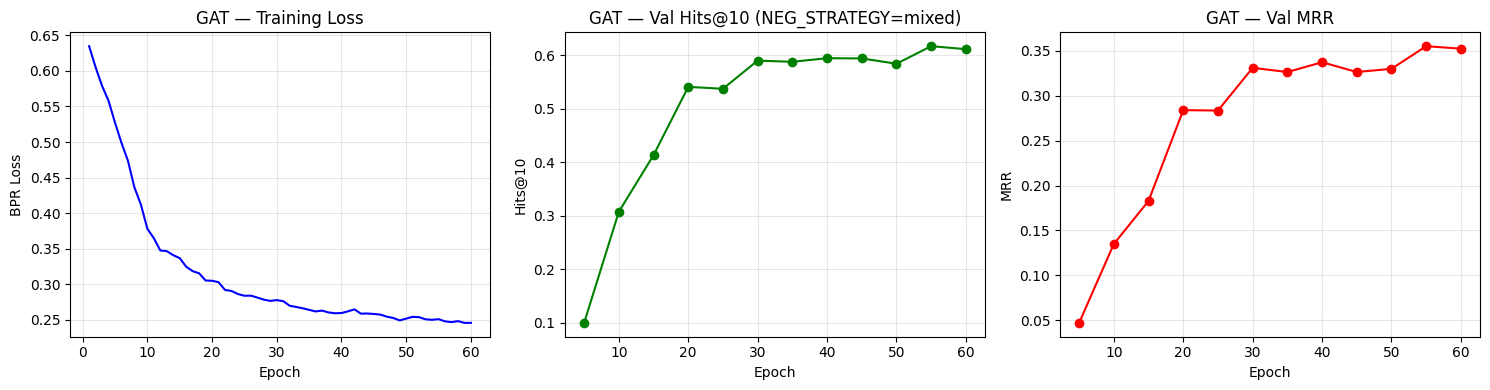

Best val Hits@10: 0.6166 (epoch 55)
Best val MRR:     0.3551 (epoch 55)


In [23]:
import matplotlib.pyplot as plt

PLOTS_OUT_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')
axes[0].set_title('GAT — Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(eval_epochs, val_hits, 'g-o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')
axes[1].set_title(f'GAT — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})'); axes[1].grid(True, alpha=0.3)
axes[2].plot(eval_epochs, val_mrrs, 'r-o')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')
axes[2].set_title('GAT — Val MRR'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOTS_OUT_DIR / f'gat_v2_training_{NEG_STRATEGY}.png'), dpi=100, bbox_inches='tight')
plt.show()
if val_hits:
    print(f"Best val Hits@10: {max(val_hits):.4f} (epoch {eval_epochs[int(np.argmax(val_hits))]})")
    print(f"Best val MRR:     {max(val_mrrs):.4f} (epoch {eval_epochs[int(np.argmax(val_mrrs))]})")

## Step 13 — Final test evaluation

Two regimes reported:
1. **1K mixed pool** — same eval composition as during training.
2. **Full pool (~546K)** — the realistic recommender number. Numbers will be substantially lower than the 1K version because the candidate set grew dramatically.


In [24]:
test_data = torch.load(PROCESSED_DIR / "test.pt", weights_only=False)

test_1k = evaluate(encoder, decoder, test_data, device, EVAL_BATCH_SIZE)
print("=" * 50)
print(f"GAT v2 (NEG_STRATEGY={NEG_STRATEGY}) — TEST")
print("=" * 50)
print(f"\n[1K mixed pool, 50/50 hard/random]")
print(f"  Hits@10: {test_1k['hits@10']:.4f}")
print(f"  MRR:     {test_1k['mrr']:.4f}")
print(f"  Authors: {test_1k['num_authors']}")

test_full = evaluate_full_pool(encoder, decoder, test_data, device)
print(f"\n[Full pool — every paper in the pre-test graph]")
print(f"  Hits@10: {test_full['hits@10']:.4f}")
print(f"  MRR:     {test_full['mrr']:.4f}")
print(f"  Authors: {test_full['num_authors']}")

GAT v2 (NEG_STRATEGY=mixed) — TEST

[1K mixed pool, 50/50 hard/random]
  Hits@10: 0.6217
  MRR:     0.3583
  Authors: 37046

[Full pool — every paper in the pre-test graph]
  Hits@10: 0.0355
  MRR:     0.0171
  Authors: 37046


## Step 14 — Save model

Persist encoder + decoder weights + config + both test numbers to `models/gat_v2_<NEG_STRATEGY>.pt`. Multiple ablation runs (`mixed`, `random`, `hard`) save under different filenames so they don't clobber each other.


In [25]:
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_OUT_DIR / f"gat_v2_{NEG_STRATEGY}.pt"

torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'config': {
        'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,
        'gat_heads_layer1': GAT_HEADS_LAYER1, 'gat_heads_layer2': GAT_HEADS_LAYER2,
        'gat_negative_slope': GAT_NEGATIVE_SLOPE,
        'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,
        'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,
        'num_epochs': NUM_EPOCHS, 'batch_size': BATCH_SIZE,
        'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,
        'neg_strategy': NEG_STRATEGY,
        'seed': SEED,
    },
    'val_best': {'hits@10': max(val_hits) if val_hits else 0.0,
                 'mrr': max(val_mrrs) if val_mrrs else 0.0},
    'test_1k_mixed': test_1k,
    'test_full_pool': test_full,
    'train_losses': train_losses,
    'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,
    'data_version': 'v2',
    'fos_level': metadata.get('fos_level'),
}, save_path)
print(f"Saved {save_path}")

Saved models/gat_v2_mixed.pt


## Summary

| Metric | Value |
|---|---|
| NEG_STRATEGY | (see config) |
| Best val Hits@10 (1K mixed) | (see plot) |
| Test Hits@10 (1K mixed) | (last eval cell) |
| Test Hits@10 (full pool) | (last eval cell) |

**Re-run for ablation**: change `NEG_STRATEGY` to `'random'` or `'hard'` and re-run all cells. Three saved checkpoints (`gat_v2_{random,hard,mixed}.pt`) give the negative-sampling ablation.
